# Telecom Customer Churn Prediction

This notebook builds a churn prediction model for a telecom company. The workflow covers exploratory data analysis, cleaning and feature engineering, encoding, and training/comparing three classifiers (XGBoost, Random Forest, and a Decision Tree baseline). Model selection is driven mainly by recall on the minority (churned) class, since missing an at-risk customer is more costly than a false alarm here, along with nested cross-validation to sanity-check that the tuned scores aren't just an artifact of the hyperparameter search.

In [39]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,f1_score,recall_score,precision_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from autoEDA import autoeda
from sklearn.model_selection import GridSearchCV, StratifiedKFold,cross_val_score,RandomizedSearchCV
from scipy.stats import ttest_rel

## 1. Data Loading

Load the raw customer dataset from Excel.

In [2]:
df = pd.read_excel("churn_pred.xlsx")

## 2. Exploratory Data Analysis

Running a quick automated EDA pass to check data types, missing values, duplicates, outliers and distributions before doing any cleaning.

SAMPLE DATA AND COLUMN NAME STANDARDISATION


,customer_id,gender,age,married,state,number_of_referrals,tenure_in_months,value_deal,phone_service,multiple_lines,...,payment_method,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,customer_status,churn_category,churn_reason
1155,65939-TAM,Male,63,No,Tamil Nadu,3,24,NaN,Yes,Yes,...,Credit Card,24.80,1514.85,0.0,0,2256.00,3770.85,Stayed,Others,Others
905,11952-RAJ,Female,45,No,Rajasthan,3,10,NaN,Yes,No,...,Credit Card,71.35,515.75,0.0,0,349.86,865.61,Stayed,Others,Others
4704,85248-KAR,Female,35,Yes,Karnataka,4,11,NaN,Yes,Yes,...,Bank Withdrawal,101.15,6638.35,0.0,30,1775.68,8444.03,Stayed,Others,Others
1116,26259-RAJ,Female,46,No,Rajasthan,4,9,Deal 3,Yes,No,...,Bank Withdrawal,20.10,682.10,0.0,0,1418.48,2100.58,Stayed,Others,Others
5872,69719-TAM,Female,36,No,Tamil Nadu,2,16,NaN,Yes,No,...,Bank Withdrawal,94.60,2283.15,0.0,0,853.44,3136.59,Stayed,Others,Others


DF DESCRIBE


,age,number_of_referrals,tenure_in_months,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue
count,6007.000000,6007.000000,6007.00000,6007.000000,6007.000000,6007.000000,6007.000000,6007.000000,6007.000000
mean,47.289163,7.439820,17.39454,65.087598,2430.986173,2.038612,7.015149,797.283311,3233.246021
std,16.805110,4.622369,10.59292,31.067808,2267.481294,8.065520,25.405737,854.858841,2856.181082
min,18.000000,0.000000,1.00000,-10.000000,19.100000,0.000000,0.000000,0.000000,21.610000
25%,33.000000,3.000000,8.00000,35.950000,539.950000,0.000000,0.000000,107.085000,833.685000
50%,47.000000,7.000000,17.00000,71.100000,1556.850000,0.000000,0.000000,470.220000,2367.150000
75%,60.000000,11.000000,27.00000,90.450000,4013.900000,0.000000,0.000000,1269.840000,5105.685000
max,84.000000,15.000000,36.00000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


DF INFO
<class 'pandas.DataFrame'>
RangeIndex: 6007 entries, 0 to 6006
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  6007 non-null   str    
 1   gender                       6007 non-null   str    
 2   age                          6007 non-null   int64  
 3   married                      6007 non-null   str    
 4   state                        6007 non-null   str    
 5   number_of_referrals          6007 non-null   int64  
 6   tenure_in_months             6007 non-null   int64  
 7   value_deal                   2710 non-null   str    
 8   phone_service                6007 non-null   str    
 9   multiple_lines               6007 non-null   str    
 10  internet_service             6007 non-null   str    
 11  internet_type                4784 non-null   str    
 12  online_security              6007 non-null   str    
 13  online_backup        

None

NULL VALUES


customer_id                       0
gender                            0
age                               0
married                           0
state                             0
number_of_referrals               0
tenure_in_months                  0
value_deal                     3297
phone_service                     0
multiple_lines                    0
internet_service                  0
internet_type                  1223
online_security                   0
online_backup                     0
device_protection_plan            0
premium_support                   0
streaming_tv                      0
streaming_movies                  0
streaming_music                   0
unlimited_data                    0
contract                          0
paperless_billing                 0
payment_method                    0
monthly_charge                    0
total_charges                     0
total_refunds                     0
total_extra_data_charges          0
total_long_distance_charges 

DUPLICATE COUNTS
0
SKEWNESS CHECK
total_charges: 0.8939
total_refunds: 4.2397
total_extra_data_charges: 4.0072
total_long_distance_charges: 1.1672
total_revenue: 0.8571
OUTLIER DETECTION (numeric_columns_only)


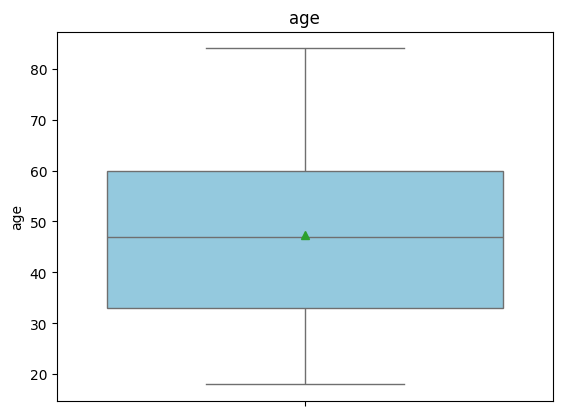

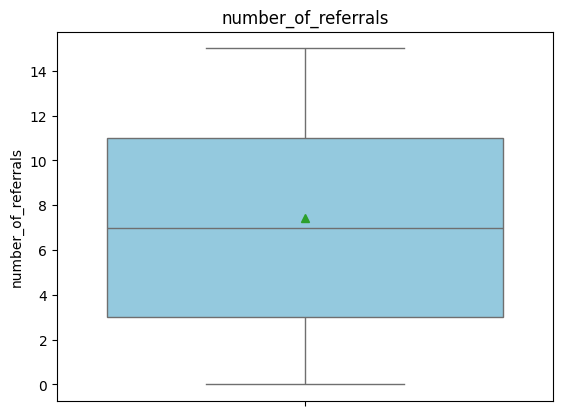

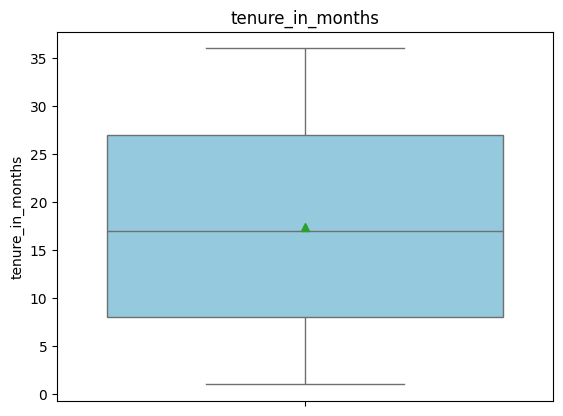

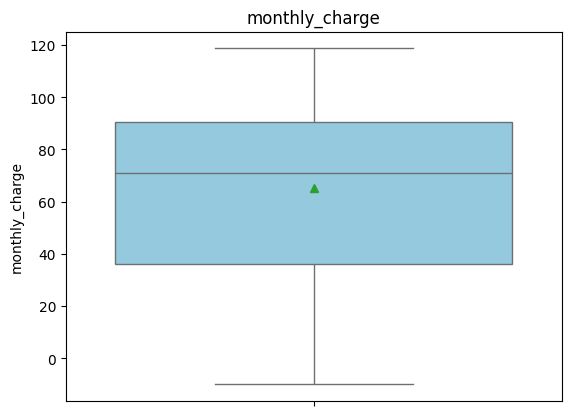

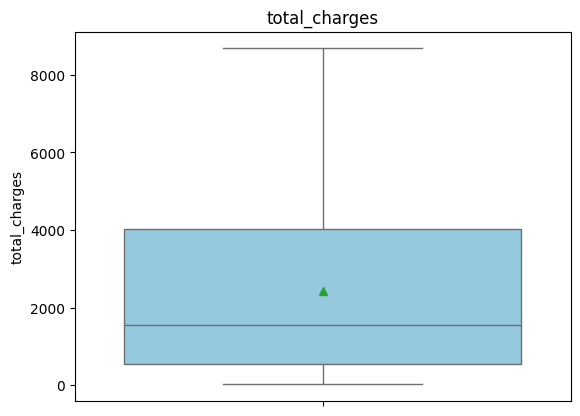

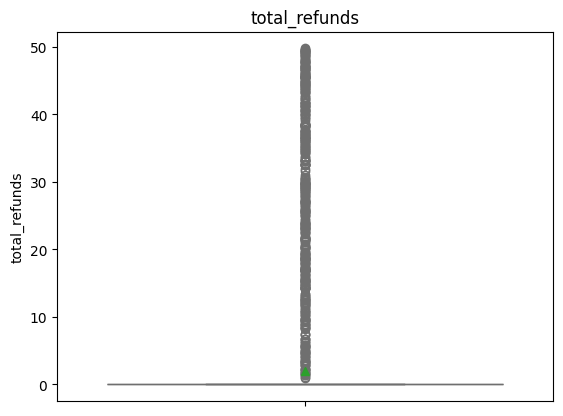

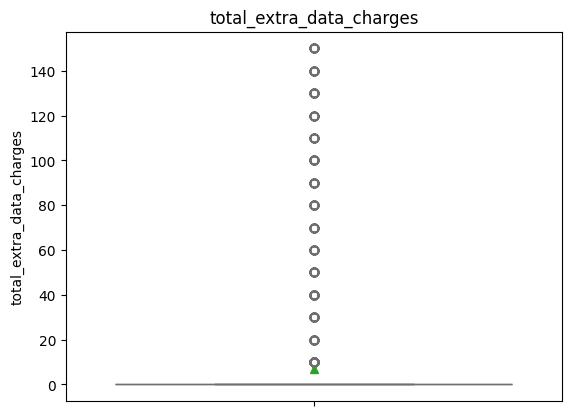

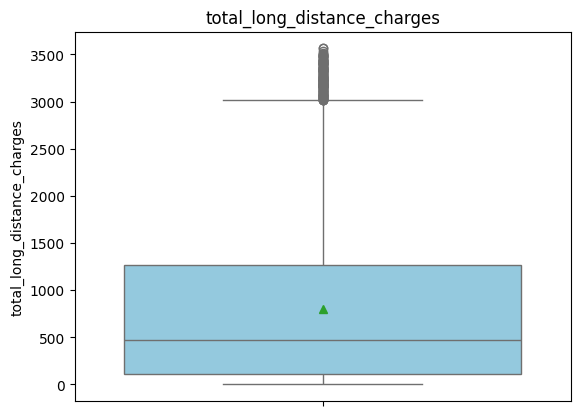

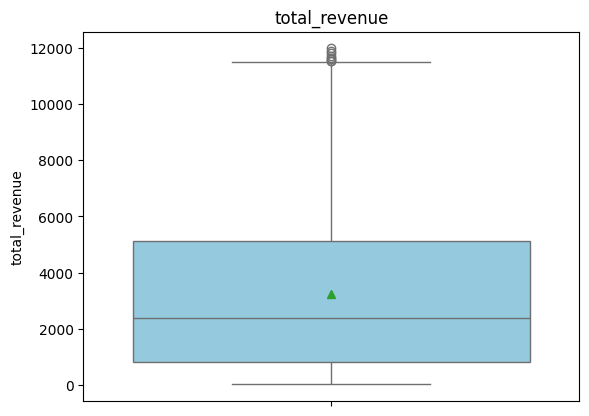

DISTRIBUTION CHECK (numeric_columns_only)


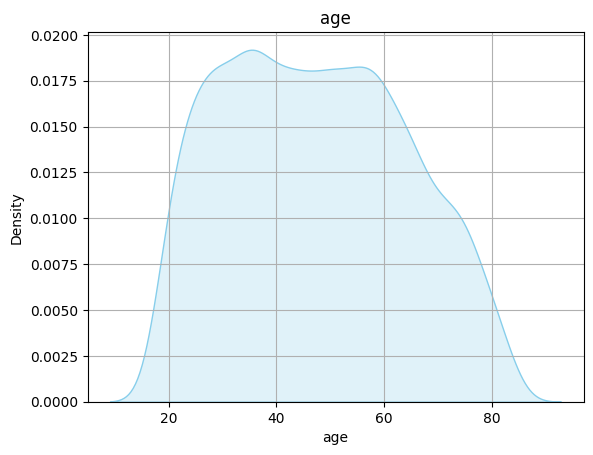

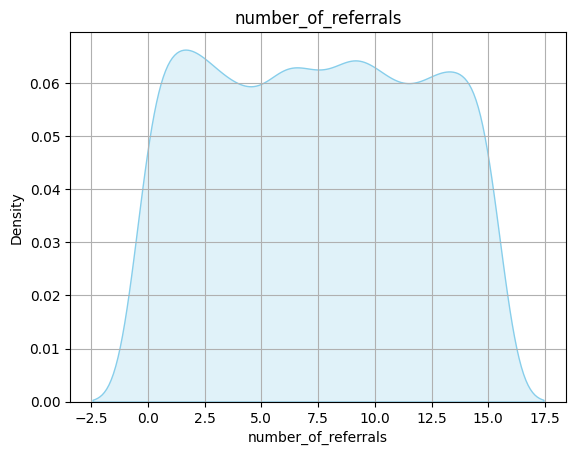

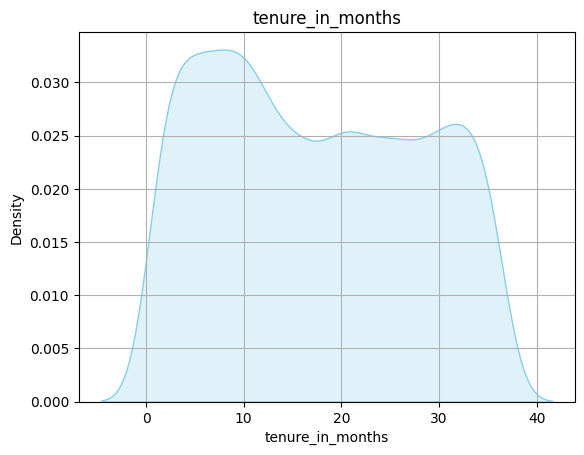

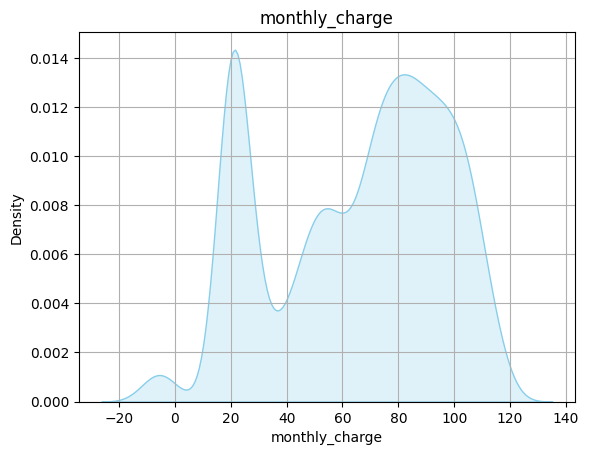

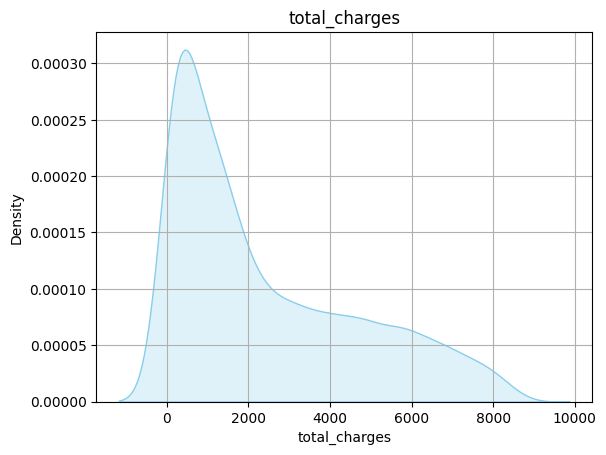

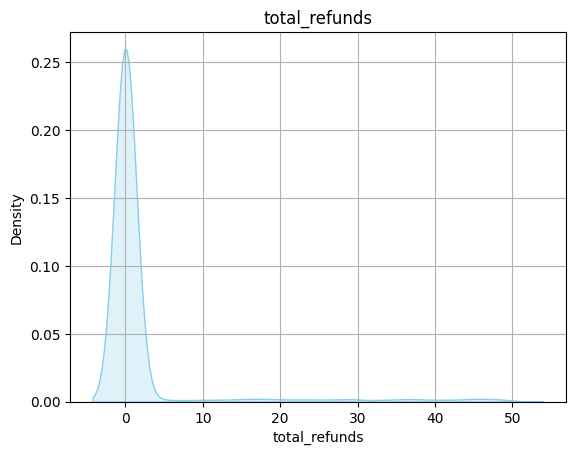

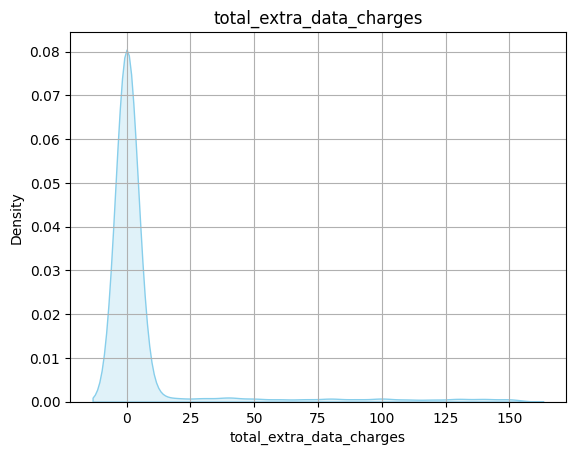

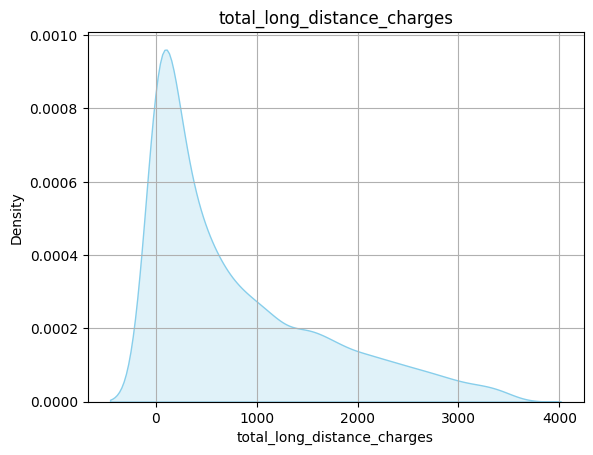

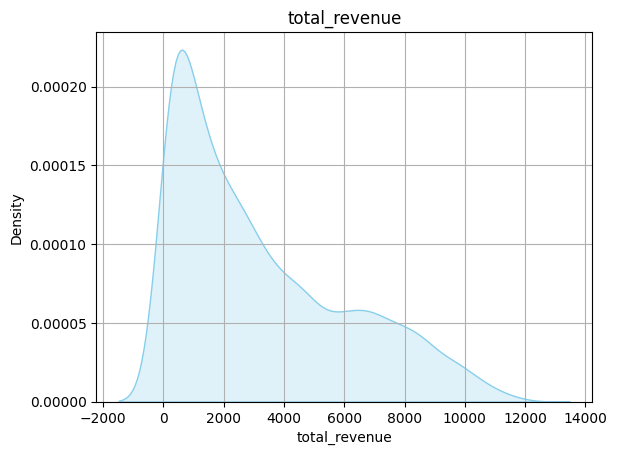

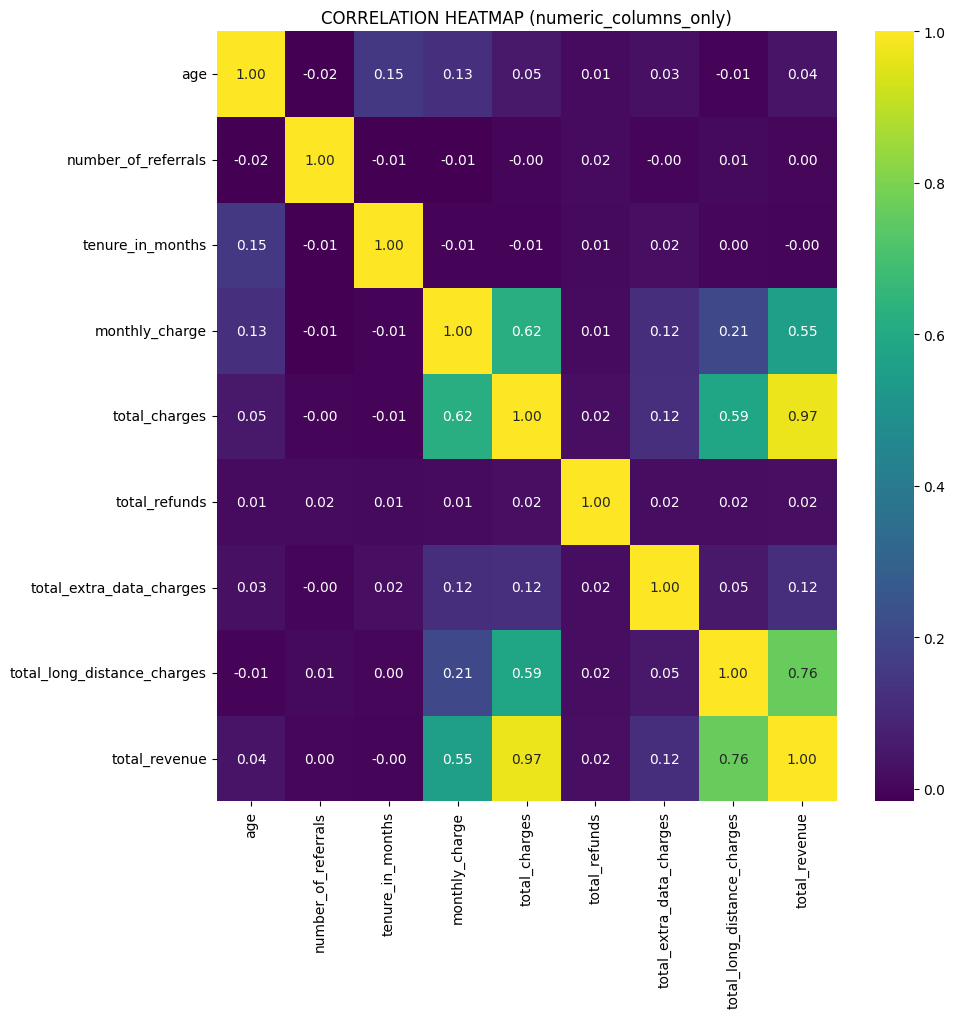

In [3]:
autoeda(df)

## 3. Data Cleaning

`value_deal` and `internet_type` have a large number of missing values, but these aren't really "missing" in the traditional sense — a customer without a `value_deal` simply isn't on a promotional deal, and one without an `internet_type` doesn't have internet service. Both are filled with an explicit `"None"` category rather than imputed.

In [4]:
df["value_deal"] = df["value_deal"].fillna("None")

In [5]:
df["internet_type"] = df["internet_type"].fillna("None")

In [6]:
df.isnull().sum()

customer_id                    0
gender                         0
age                            0
married                        0
state                          0
number_of_referrals            0
tenure_in_months               0
value_deal                     0
phone_service                  0
multiple_lines                 0
internet_service               0
internet_type                  0
online_security                0
online_backup                  0
device_protection_plan         0
premium_support                0
streaming_tv                   0
streaming_movies               0
streaming_music                0
unlimited_data                 0
contract                       0
paperless_billing              0
payment_method                 0
monthly_charge                 0
total_charges                  0
total_refunds                  0
total_extra_data_charges       0
total_long_distance_charges    0
total_revenue                  0
customer_status                0
churn_cate

### Removing data leakage

`churn_reason` and `churn_category` are only known *after* a customer has churned — including them would leak the target into the features. `customer_id` is just an identifier and carries no predictive signal, so it's dropped as well.

In [7]:
df.drop(["churn_reason","customer_id","churn_category"],axis=1,inplace=True)

### Feature engineering: refunds and extra data charges

Both `total_refunds` and `total_extra_data_charges` are heavily skewed, with the large majority of values sitting at exactly zero. Rather than feeding the raw skewed amounts into the model, they're converted into simple binary flags indicating whether a customer received a refund or was charged for extra data — the presence of the event is more informative here than the exact amount.

In [8]:
print('total_refunds zero %:', (df['total_refunds'] == 0).mean())
print('total_extra_data_charges zero %:', (df['total_extra_data_charges'] == 0).mean())

total_refunds zero %: 0.9230897286499085
total_extra_data_charges zero %: 0.8977859164308307


In [9]:
df['has_refund'] = (df['total_refunds'] > 0).astype(int)
df['has_extra_data_charge'] = (df['total_extra_data_charges'] > 0).astype(int)

In [10]:
df.drop(["total_refunds","total_extra_data_charges"],axis=1,inplace=True)

## 4. Encoding Categorical Variables

The target column `customer_status` is mapped to a binary label (0 = Stayed, 1 = Churned). The remaining categorical columns are label-encoded so they can be used by the tree-based models.

In [11]:
lb = LabelEncoder()

In [12]:
catcol = df.select_dtypes(include=str).columns.to_list()

In [13]:
catcol.remove("customer_status")

In [14]:
catcol

['gender',
 'married',
 'state',
 'value_deal',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'internet_type',
 'online_security',
 'online_backup',
 'device_protection_plan',
 'premium_support',
 'streaming_tv',
 'streaming_movies',
 'streaming_music',
 'unlimited_data',
 'contract',
 'paperless_billing',
 'payment_method']

In [15]:
df["customer_status"] = df["customer_status"].map({"Stayed":0,"Churned":1})

In [16]:
for cat in catcol:
    df[cat] = lb.fit_transform(df[cat])

## 5. Train/Test Split

Splitting the data into training and test sets (80/20) before any model fitting or tuning, so the test set stays unseen until final evaluation.

In [17]:
X = df.drop("customer_status",axis=1)
y = df["customer_status"]

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

## 6. Model 1: XGBoost

### Hyperparameter tuning

Churn is an imbalanced classification problem, so `scale_pos_weight` is computed from the class ratio in the training set and passed into the grid search. Tuning is done with `GridSearchCV` using stratified 5-fold CV, optimizing for recall on the churned class.

In [19]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(scale_pos_weight)
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
     'scale_pos_weight': [scale_pos_weight]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'),
                         param_grid_xgb, cv=cv, scoring='recall', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
print(grid_xgb.best_params_)
print(grid_xgb.best_score_)
best_model = grid_xgb.best_estimator_

2.5047410649161197
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'scale_pos_weight': np.float64(2.5047410649161197), 'subsample': 1.0}
0.8286237558062375


### Training and evaluating the tuned XGBoost model

Refitting XGBoost with the best parameters found above, then checking training score, 10-fold cross-validated recall, and the full classification report on the held-out test set.

In [20]:
xbp = {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': np.float64(2.5047410649161197), 'subsample': 0.8}
xb = XGBClassifier(**xbp)

In [21]:
xb.fit(X_train,y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [22]:
xbpred = xb.predict(X_test)
xb.score(X_train,y_train)

0.8054110301768991

In [23]:
scores = cross_val_score(xb, X_train, y_train, cv=10, scoring='recall')
print(scores)
print('Mean recall:', scores.mean())
print('Std dev:', scores.std())

[0.81021898 0.76642336 0.81021898 0.78832117 0.80434783 0.8540146
 0.8540146  0.84671533 0.83941606 0.81751825]
Mean recall: 0.819120913995557
Std dev: 0.027773083069132228


In [24]:
print(precision_score(y_test, xbpred))

0.6389496717724289


In [25]:
print(classification_report(y_test,xbpred))

              precision    recall  f1-score   support

           0       0.91      0.80      0.85       841
           1       0.64      0.81      0.71       361

    accuracy                           0.81      1202
   macro avg       0.77      0.81      0.78      1202
weighted avg       0.83      0.81      0.81      1202



## 7. Model 2: Random Forest

### Hyperparameter tuning

`RandomizedSearchCV` is used here instead of an exhaustive grid search to keep runtime reasonable, again optimizing for recall with `class_weight='balanced_subsample'` to account for the class imbalance.

In [26]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 12],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 2],
    'max_features': [0.5, 'sqrt'],
    'class_weight': ['balanced_subsample']
}

rf = RandomForestClassifier(random_state=42)
search = RandomizedSearchCV(rf, param_dist, n_iter=40, cv=5,
                             scoring='recall', n_jobs=-1, random_state=42)
search.fit(X_train, y_train)
print(search.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5, 'class_weight': 'balanced_subsample'}


### Training and evaluating Random Forest

Refitting with the best parameters and checking the same set of metrics as for XGBoost — accuracy, F1, recall, cross-validated recall, precision, confusion matrix, and the classification report — so the two models can be compared directly.

In [27]:
rfpram=param_grid_rf = {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5, 'class_weight': 'balanced_subsample'}
rf = RandomForestClassifier(**rfpram,random_state=42)


In [28]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [29]:
rfpred = rf.predict(X_test)
rf.score(X_train, y_train)

0.8164412070759626

In [30]:
print(accuracy_score(y_test, rfpred))
print(f1_score(y_test, rfpred))
print(recall_score(y_test, rfpred))
scores = cross_val_score(rf, X_train, y_train, cv=10, scoring='recall')
print(scores)
print('Mean recall:', scores.mean())
print('Std dev:', scores.std())
print(precision_score(y_test, rfpred))
print(confusion_matrix(y_test, rfpred))
print(classification_report(y_test,rfpred))

0.8161397670549085
0.7301587301587301
0.8282548476454293
[0.81021898 0.77372263 0.83941606 0.7810219  0.82608696 0.8540146
 0.84671533 0.86861314 0.86131387 0.81751825]
Mean recall: 0.8278641701047287
Std dev: 0.03082056528668415
0.6528384279475983
[[682 159]
 [ 62 299]]
              precision    recall  f1-score   support

           0       0.92      0.81      0.86       841
           1       0.65      0.83      0.73       361

    accuracy                           0.82      1202
   macro avg       0.78      0.82      0.80      1202
weighted avg       0.84      0.82      0.82      1202



## 8. Model 3: Decision Tree (baseline comparison)

A single decision tree is included mainly as a simple, interpretable baseline to see how much the ensemble methods above are actually buying in terms of performance. Several class-weighting schemes are included in the grid search alongside `'balanced'`.

In [31]:
param_grid = {
    'criterion':["gini","entropy","log_loss"],
    'max_depth': [5, 10,12, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [
        {0: 1, 1: 0.1},
        {0: 1, 1: 0.5},
        {0: 1, 1: 0.9},
        'balanced'
    ],
}
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=param_grid,
    cv=5,                    
    scoring='recall',      
    n_jobs=-1,               
    verbose=2
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
0.8183543463835434


### Training and evaluating the Decision Tree

In [32]:
pram={'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 5}
dc = DecisionTreeClassifier(**pram)
dc.fit(X_train,y_train)
dcpred = dc.predict(X_test)
dc.score(X_train,y_train)

0.7925078043704474

In [33]:
print(accuracy_score(y_test, dcpred))
print(f1_score(y_test, dcpred))
print(recall_score(y_test, dcpred))
scores = cross_val_score(dc, X_train, y_train, cv=10, scoring='recall')
print(scores)
print('Mean recall:', scores.mean())
print('Std dev:', scores.std())
print(precision_score(y_test, dcpred))
print(confusion_matrix(y_test, dcpred))
print(classification_report(y_test,dcpred))

0.781198003327787
0.6994285714285714
0.8476454293628809
[0.81751825 0.79562044 0.82481752 0.83941606 0.86231884 0.79562044
 0.86861314 0.83941606 0.83941606 0.84671533]
Mean recall: 0.8329472125251243
Std dev: 0.023538417130535585
0.5953307392996109
[[633 208]
 [ 55 306]]
              precision    recall  f1-score   support

           0       0.92      0.75      0.83       841
           1       0.60      0.85      0.70       361

    accuracy                           0.78      1202
   macro avg       0.76      0.80      0.76      1202
weighted avg       0.82      0.78      0.79      1202



## 9. Robustness Check: Nested Cross-Validation

A single train/test split and a single round of hyperparameter tuning can overstate how well a model generalizes, since the same data effectively gets used for both tuning and evaluation. Nested cross-validation (an outer CV loop for evaluation wrapped around an inner CV loop for tuning) gives a more honest estimate of how the tuning procedure itself performs, rather than just the one selected model.

### XGBoost

In [34]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [scale_pos_weight]  # fixed at your computed value
}

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

grid_xgb_nested = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid_xgb,
    cv=inner_cv,
    scoring='recall',
    n_jobs=-1
)

nested_scores = cross_val_score(grid_xgb_nested, X_train, y_train, cv=outer_cv, scoring='recall')

print(nested_scores)

[0.84671533 0.81751825 0.81386861 0.85766423 0.82181818]


In [35]:
print('Nested CV mean recall:', nested_scores.mean())
print('Nested CV std dev:', nested_scores.std())

Nested CV mean recall: 0.831516921035169
Nested CV std dev: 0.01741358491212647


### Random Forest

In [36]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 12],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 2],
    'max_features': [0.5, 'sqrt'],
    'class_weight': ['balanced_subsample']
}

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

grid_rf_nested = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=inner_cv,
    scoring='recall',
    n_jobs=-1
)

nested_scores_rf = cross_val_score(grid_rf_nested, X_train, y_train, cv=outer_cv, scoring='recall')

print(nested_scores_rf)

[0.83211679 0.83211679 0.80291971 0.85766423 0.83272727]


In [37]:
print('Nested CV mean recall (RF):', nested_scores_rf.mean())
print('Nested CV std dev (RF):', nested_scores_rf.std())

Nested CV mean recall (RF): 0.8315089581950895
Nested CV std dev (RF): 0.01734166578248185


In [38]:
param_grid_dt= {
    'criterion':["gini","entropy","log_loss"],
    'max_depth': [5, 10,12, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [
        {0: 1, 1: 0.1},
        {0: 1, 1: 0.5},
        {0: 1, 1: 0.9},
        'balanced'
    ],
}
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

grid_dt_nested = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=inner_cv,
    scoring='recall',
    n_jobs=-1
)

nested_scores_dt= cross_val_score(grid_dt_nested, X_train, y_train, cv=outer_cv, scoring='recall')

print(nested_scores_dt)
print('Nested CV mean recall (DT):', nested_scores_dt.mean())
print('Nested CV std dev (DT):', nested_scores_dt.std())

[0.8649635  0.75547445 0.76642336 0.81021898 0.77454545]
Nested CV mean recall (DT): 0.7943251493032515
Nested CV std dev (DT): 0.03980330096330817


In [40]:
ttest_rel(nested_scores_rf, nested_scores_dt)

TtestResult(statistic=np.float64(1.9864324920096088), pvalue=np.float64(0.11793067786610495), df=np.int64(4))

## 10. Conclusion

On the held-out test set, all three models land in a similar range on churn recall: XGBoost 0.81, Random Forest 0.83, and the Decision Tree 0.85. The Decision Tree's higher recall comes at a real cost in precision, though — 0.595, versus 0.64 for XGBoost and 0.65 for Random Forest — meaning it flags more churners but at the cost of a lot more false positives.

The 10-fold CV recall estimates on the training set tell a similar story (XGBoost 0.819 ± 0.028, Random Forest 0.828 ± 0.031, Decision Tree 0.833 ± 0.024), with all three models overlapping once the standard deviations are taken into account. Nested cross-validation was only run for XGBoost and Random Forest, and the two come out essentially tied (0.8315 ± 0.017 for both) — there's no meaningful gap here, and no significance test was run to confirm even that small difference is real. The Decision Tree wasn't put through the same nested CV check, so its single-split numbers should be treated with more caution.

Overall, none of the three models is decisively better across the board. Random Forest's test metrics land between the other two on essentially every measure. Between XGBoost and Random Forest, the nested CV results are close enough to call it a tie. Decision Tree gets the highest raw recall but only by trading away a meaningful chunk of precision, and its results carry more uncertainty since they weren't nested-CV checked. Which model to prefer in production would come down to a business call: XGBoost/Random Forest for a better recall-precision balance, or the Decision Tree if catching the maximum number of churners is worth the extra false positives — and even then, that trade-off should probably be tuned via the decision threshold rather than by picking the Decision Tree specifically.
